In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

# =========================================================
# Notebook 03: build tract-level demographic master table
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

houston_tract_path = data_processed / "houston" / "houston_city_tracts.gpkg"
phoenix_tract_path = data_processed / "phoenix" / "phoenix_city_tracts.gpkg"

houston_gdf = gpd.read_file(houston_tract_path, layer="tracts")
phoenix_gdf = gpd.read_file(phoenix_tract_path, layer="tracts")

houston_gdf["GEOID"] = houston_gdf["GEOID"].astype(str)
phoenix_gdf["GEOID"] = phoenix_gdf["GEOID"].astype(str)

print("Houston tracts:", len(houston_gdf))
print("Phoenix tracts:", len(phoenix_gdf))

display(houston_gdf.head(2))
display(phoenix_gdf.head(2))

Houston tracts: 654
Phoenix tracts: 373


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,ALAND,AWATER,area_km2,city,geometry
0,48,201,421101,48201421101,4211.01,Census Tract 4211.01,1238555,0,1.239311,Houston,"POLYGON ((260450.376 3290821.22, 260452.777 32..."
1,48,201,423301,48201423301,4233.01,Census Tract 4233.01,1654036,22924,1.678074,Houston,"POLYGON ((255324.443 3285194.428, 255494.986 3..."


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,ALAND,AWATER,area_km2,city,geometry
0,04,013,117200,04013117200,1172,Census Tract 1172,7360771,0,7.356595,Phoenix,"POLYGON ((400977.05 3699411.24, 400977.764 369..."
1,04,013,082016,04013082016,820.16,Census Tract 820.16,5194775,1855,5.194239,Phoenix,"POLYGON ((381812.504 3708357.713, 381812.61 37..."


Houston tracts: 654
Phoenix tracts: 373


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,ALAND,AWATER,area_km2,city,geometry
0,48,201,421101,48201421101,4211.01,Census Tract 4211.01,1238555,0,1.239311,Houston,"POLYGON ((260450.376 3290821.22, 260452.777 32..."
1,48,201,423301,48201423301,4233.01,Census Tract 4233.01,1654036,22924,1.678074,Houston,"POLYGON ((255324.443 3285194.428, 255494.986 3..."


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,ALAND,AWATER,area_km2,city,geometry
0,04,013,117200,04013117200,1172,Census Tract 1172,7360771,0,7.356595,Phoenix,"POLYGON ((400977.05 3699411.24, 400977.764 369..."
1,04,013,082016,04013082016,820.16,Census Tract 820.16,5194775,1855,5.194239,Phoenix,"POLYGON ((381812.504 3708357.713, 381812.61 37..."



Houston ACS sample:


,city,GEOID,NAME,total_population,median_household_income
0,Houston,48157670101,Census Tract 6701.01; Fort Bend County; Texas,6123,62454
1,Houston,48157670102,Census Tract 6701.02; Fort Bend County; Texas,3348,70198
2,Houston,48157670201,Census Tract 6702.01; Fort Bend County; Texas,1687,105456
3,Houston,48157670202,Census Tract 6702.02; Fort Bend County; Texas,5107,57017
4,Houston,48157670300,Census Tract 6703; Fort Bend County; Texas,3429,49038



Phoenix ACS sample:


,city,GEOID,NAME,total_population,median_household_income
0,Phoenix,04013010102,Census Tract 101.02; Maricopa County; Arizona,6265,188486
1,Phoenix,04013010103,Census Tract 101.03; Maricopa County; Arizona,3681,117813
2,Phoenix,04013010104,Census Tract 101.04; Maricopa County; Arizona,3131,140587
3,Phoenix,04013030401,Census Tract 304.01; Maricopa County; Arizona,4744,145865
4,Phoenix,04013030402,Census Tract 304.02; Maricopa County; Arizona,4153,108031



ACS QC:


,city,tract_rows,unique_geoids,missing_pop_after_merge,missing_income_after_merge,invalid_income_after_clean,median_income_clean_median,population_clean_sum
0,Houston,654,654,0,0,9,60167.0,2314658
1,Phoenix,373,373,0,0,5,75744.0,1613480


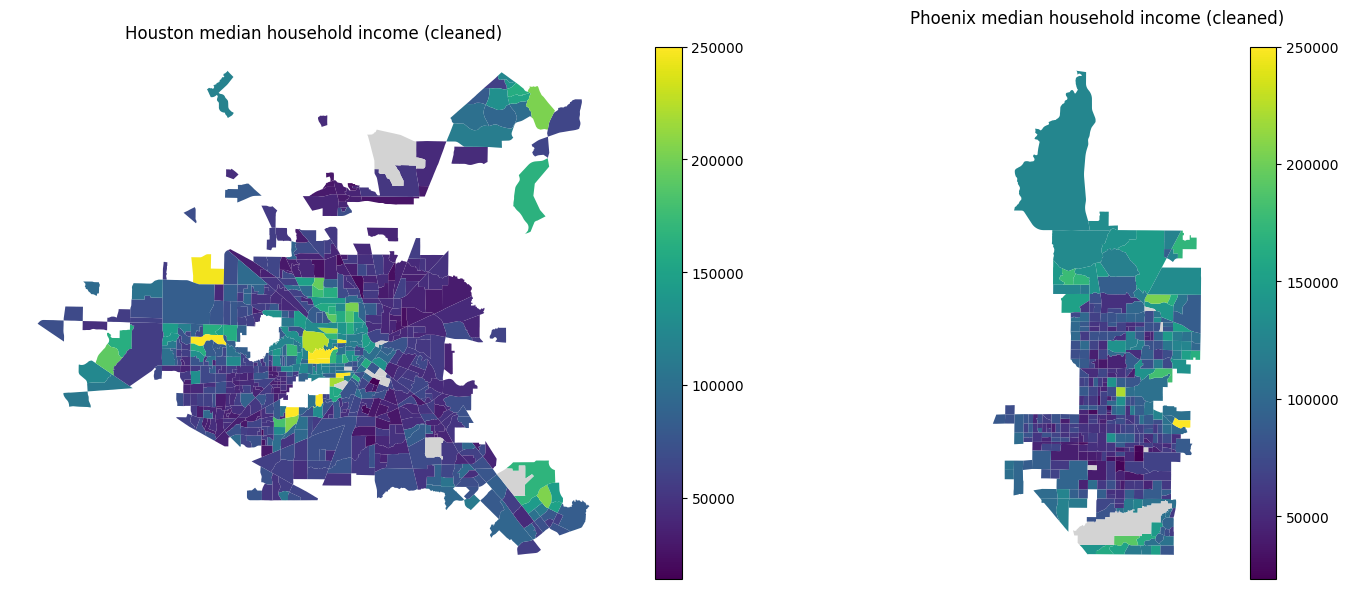


Block 1 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/houston_acs_2023.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/phoenix_acs_2023.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/acs_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/income_qc_map_clean.png -> True


In [2]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

# =========================================================
# Notebook 03: build tract-level demographic master table
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

houston_tract_path = data_processed / "houston" / "houston_city_tracts.gpkg"
phoenix_tract_path = data_processed / "phoenix" / "phoenix_city_tracts.gpkg"

houston_gdf = gpd.read_file(houston_tract_path, layer="tracts")
phoenix_gdf = gpd.read_file(phoenix_tract_path, layer="tracts")

houston_gdf["GEOID"] = houston_gdf["GEOID"].astype(str)
phoenix_gdf["GEOID"] = phoenix_gdf["GEOID"].astype(str)

print("Houston tracts:", len(houston_gdf))
print("Phoenix tracts:", len(phoenix_gdf))

display(houston_gdf.head(2))
display(phoenix_gdf.head(2))

# --------------------------------------------------
# ACS helper functions
# --------------------------------------------------

ACS_YEAR = "2023"
ACS_BASE = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5"

def get_city_counties(gdf: gpd.GeoDataFrame, city_name: str) -> pd.DataFrame:
    out = (
        gdf[["STATEFP", "COUNTYFP"]]
        .astype(str)
        .drop_duplicates()
        .sort_values(["STATEFP", "COUNTYFP"])
        .reset_index(drop=True)
    )
    out["city"] = city_name
    return out

def fetch_acs_tract_data_for_county(state_fips: str, county_fips: str, variables: list[str]) -> pd.DataFrame:
    var_string = ",".join(["NAME"] + variables)
    url = (
        f"{ACS_BASE}"
        f"?get={var_string}"
        f"&for=tract:*"
        f"&in=state:{state_fips}"
        f"&in=county:{county_fips}"
    )

    r = requests.get(url, timeout=60)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])

    df["state"] = df["state"].astype(str)
    df["county"] = df["county"].astype(str)
    df["tract"] = df["tract"].astype(str)
    df["GEOID"] = df["state"] + df["county"] + df["tract"]

    for v in variables:
        df[v] = pd.to_numeric(df[v], errors="coerce")

    return df

def fetch_city_acs(gdf: gpd.GeoDataFrame, city_name: str, vars_to_fetch: list[str]) -> pd.DataFrame:
    county_df = get_city_counties(gdf, city_name)

    parts = []
    for _, row in county_df.iterrows():
        state_fips = row["STATEFP"]
        county_fips = row["COUNTYFP"]

        print(f"Downloading ACS for {city_name}: state={state_fips}, county={county_fips}, vars={vars_to_fetch}")
        part = fetch_acs_tract_data_for_county(
            state_fips=state_fips,
            county_fips=county_fips,
            variables=vars_to_fetch
        )
        parts.append(part)

    acs_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset="GEOID").copy()
    acs_df["city"] = city_name
    return acs_df

# --------------------------------------------------
# Step 1: total population + median household income
# --------------------------------------------------

BASE_VARS = [
    "B01003_001E",  # total population
    "B19013_001E"   # median household income
]

houston_acs = fetch_city_acs(houston_gdf, "Houston", BASE_VARS)
phoenix_acs = fetch_city_acs(phoenix_gdf, "Phoenix", BASE_VARS)

houston_acs = houston_acs.rename(columns={
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income"
})
phoenix_acs = phoenix_acs.rename(columns={
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income"
})

print("\nHouston ACS sample:")
display(houston_acs[["city", "GEOID", "NAME", "total_population", "median_household_income"]].head())

print("\nPhoenix ACS sample:")
display(phoenix_acs[["city", "GEOID", "NAME", "total_population", "median_household_income"]].head())

# --------------------------------------------------
# Step 2: merge ACS back to tract layers
# --------------------------------------------------

houston_master = houston_gdf.copy()
phoenix_master = phoenix_gdf.copy()

houston_master = houston_master.merge(
    houston_acs[["GEOID", "total_population", "median_household_income"]],
    on="GEOID",
    how="left"
)

phoenix_master = phoenix_master.merge(
    phoenix_acs[["GEOID", "total_population", "median_household_income"]],
    on="GEOID",
    how="left"
)

# --------------------------------------------------
# Step 3: clean special values
# --------------------------------------------------

for gdf in [houston_master, phoenix_master]:
    gdf["total_population_clean"] = gdf["total_population"].where(gdf["total_population"] >= 0)
    gdf["median_household_income_clean"] = gdf["median_household_income"].where(gdf["median_household_income"] >= 0)

acs_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_master),
        "unique_geoids": houston_master["GEOID"].nunique(),
        "missing_pop_after_merge": houston_master["total_population"].isna().sum(),
        "missing_income_after_merge": houston_master["median_household_income"].isna().sum(),
        "invalid_income_after_clean": houston_master["median_household_income_clean"].isna().sum() - houston_master["median_household_income"].isna().sum(),
        "median_income_clean_median": houston_master["median_household_income_clean"].median(skipna=True),
        "population_clean_sum": houston_master["total_population_clean"].sum(skipna=True),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_master),
        "unique_geoids": phoenix_master["GEOID"].nunique(),
        "missing_pop_after_merge": phoenix_master["total_population"].isna().sum(),
        "missing_income_after_merge": phoenix_master["median_household_income"].isna().sum(),
        "invalid_income_after_clean": phoenix_master["median_household_income_clean"].isna().sum() - phoenix_master["median_household_income"].isna().sum(),
        "median_income_clean_median": phoenix_master["median_household_income_clean"].median(skipna=True),
        "population_clean_sum": phoenix_master["total_population_clean"].sum(skipna=True),
    }
])

print("\nACS QC:")
display(acs_qc)

# --------------------------------------------------
# Step 4: save intermediate master tables
# --------------------------------------------------

houston_master_demo_out = data_processed / "houston" / "houston_master_demo.gpkg"
phoenix_master_demo_out = data_processed / "phoenix" / "phoenix_master_demo.gpkg"

houston_master.to_file(houston_master_demo_out, layer="tracts", driver="GPKG")
phoenix_master.to_file(phoenix_master_demo_out, layer="tracts", driver="GPKG")

houston_acs_csv = output_dir / "houston_acs_2023.csv"
phoenix_acs_csv = output_dir / "phoenix_acs_2023.csv"
acs_qc_csv = output_dir / "acs_qc.csv"

houston_acs.to_csv(houston_acs_csv, index=False)
phoenix_acs.to_csv(phoenix_acs_csv, index=False)
acs_qc.to_csv(acs_qc_csv, index=False)

# --------------------------------------------------
# Step 5: quick cleaned income QC map
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master.plot(
    column="median_household_income_clean",
    ax=axes[0],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing / invalid"}
)
axes[0].set_title("Houston median household income (cleaned)")
axes[0].set_axis_off()

phoenix_master.plot(
    column="median_household_income_clean",
    ax=axes[1],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing / invalid"}
)
axes[1].set_title("Phoenix median household income (cleaned)")
axes[1].set_axis_off()

plt.tight_layout()
income_clean_map_out = figure_dir / "income_qc_map_clean.png"
plt.savefig(income_clean_map_out, dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Final check for this block
# --------------------------------------------------

block1_files = [
    houston_master_demo_out,
    phoenix_master_demo_out,
    houston_acs_csv,
    phoenix_acs_csv,
    acs_qc_csv,
    income_clean_map_out
]

print("\nBlock 1 file check:")
for p in block1_files:
    print(p, "->", p.exists())


Houston poverty ACS sample:


,city,GEOID,NAME,poverty_universe,below_poverty_count
0,Houston,48157670101,Census Tract 6701.01; Fort Bend County; Texas,6102,1053
1,Houston,48157670102,Census Tract 6701.02; Fort Bend County; Texas,3184,252
2,Houston,48157670201,Census Tract 6702.01; Fort Bend County; Texas,1687,44
3,Houston,48157670202,Census Tract 6702.02; Fort Bend County; Texas,5107,1119
4,Houston,48157670300,Census Tract 6703; Fort Bend County; Texas,3429,1011



Phoenix poverty ACS sample:


,city,GEOID,NAME,poverty_universe,below_poverty_count
0,Phoenix,04013010102,Census Tract 101.02; Maricopa County; Arizona,6265,762
1,Phoenix,04013010103,Census Tract 101.03; Maricopa County; Arizona,3681,473
2,Phoenix,04013010104,Census Tract 101.04; Maricopa County; Arizona,3131,140
3,Phoenix,04013030401,Census Tract 304.01; Maricopa County; Arizona,4672,406
4,Phoenix,04013030402,Census Tract 304.02; Maricopa County; Arizona,4153,263



Poverty QC:


,city,tract_rows,missing_poverty_universe,missing_below_poverty,missing_poverty_rate,median_poverty_rate,mean_poverty_rate
0,Houston,654,0,0,3,0.187448,0.198415
1,Phoenix,373,0,0,3,0.129445,0.152083



Inequity group counts:


,city,inequity_group,count
0,Houston,Low income + High poverty,271
1,Houston,High income + Low poverty,269
2,Houston,High income + High poverty,53
3,Houston,Low income + Low poverty,52
4,Houston,Missing,9
5,Phoenix,Low income + High poverty,147
6,Phoenix,High income + Low poverty,147
7,Phoenix,Low income + Low poverty,37
8,Phoenix,High income + High poverty,37
9,Phoenix,Missing,5


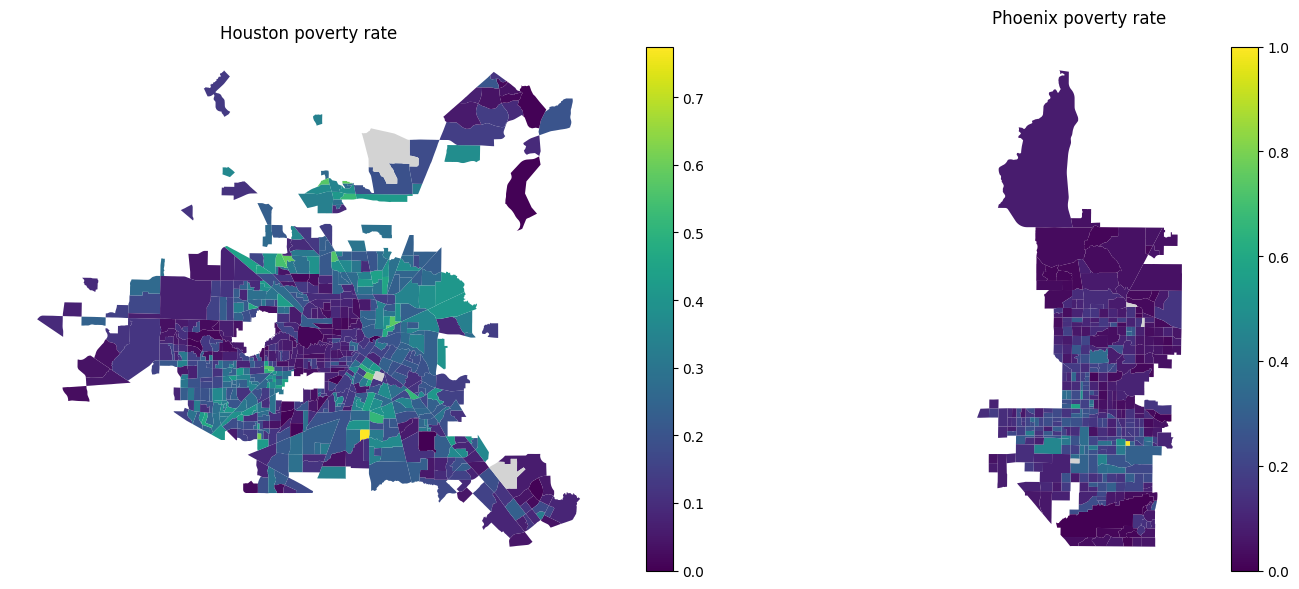

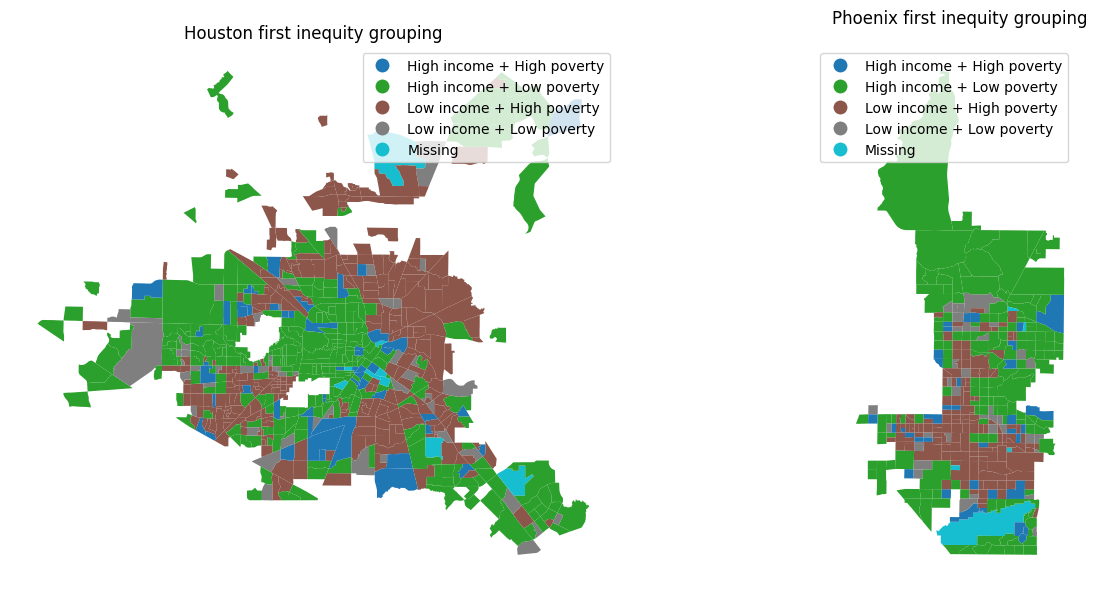


Block 2 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo_poverty.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo_poverty.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/poverty_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/inequity_group_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/poverty_rate_map.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/inequity_group_map.png -> True


In [3]:
# =========================================================
# Notebook 03 - Block 2
# Add poverty variables + build first inequity grouping
# =========================================================

POVERTY_VARS = [
    "B17001_001E",  # poverty universe total
    "B17001_002E",  # below poverty level
]

# --------------------------------------------------
# Step 6: download poverty ACS
# --------------------------------------------------

houston_poverty_acs = fetch_city_acs(houston_gdf, "Houston", POVERTY_VARS)
phoenix_poverty_acs = fetch_city_acs(phoenix_gdf, "Phoenix", POVERTY_VARS)

houston_poverty_acs = houston_poverty_acs.rename(columns={
    "B17001_001E": "poverty_universe",
    "B17001_002E": "below_poverty_count"
})
phoenix_poverty_acs = phoenix_poverty_acs.rename(columns={
    "B17001_001E": "poverty_universe",
    "B17001_002E": "below_poverty_count"
})

print("\nHouston poverty ACS sample:")
display(houston_poverty_acs[["city", "GEOID", "NAME", "poverty_universe", "below_poverty_count"]].head())

print("\nPhoenix poverty ACS sample:")
display(phoenix_poverty_acs[["city", "GEOID", "NAME", "poverty_universe", "below_poverty_count"]].head())

# --------------------------------------------------
# Step 7: merge poverty ACS back to master tables
# --------------------------------------------------

houston_master_v2 = houston_master.copy()
phoenix_master_v2 = phoenix_master.copy()

# if rerun, drop old columns first
drop_cols = [
    "poverty_universe",
    "below_poverty_count",
    "poverty_universe_clean",
    "below_poverty_count_clean",
    "poverty_rate",
    "low_income_flag",
    "high_poverty_flag",
    "inequity_group"
]

houston_master_v2 = houston_master_v2.drop(columns=[c for c in drop_cols if c in houston_master_v2.columns], errors="ignore")
phoenix_master_v2 = phoenix_master_v2.drop(columns=[c for c in drop_cols if c in phoenix_master_v2.columns], errors="ignore")

houston_master_v2 = houston_master_v2.merge(
    houston_poverty_acs[["GEOID", "poverty_universe", "below_poverty_count"]],
    on="GEOID",
    how="left"
)

phoenix_master_v2 = phoenix_master_v2.merge(
    phoenix_poverty_acs[["GEOID", "poverty_universe", "below_poverty_count"]],
    on="GEOID",
    how="left"
)

# --------------------------------------------------
# Step 8: clean poverty values and compute poverty_rate
# --------------------------------------------------

for gdf in [houston_master_v2, phoenix_master_v2]:
    # clean negative/special values
    gdf["poverty_universe_clean"] = gdf["poverty_universe"].where(gdf["poverty_universe"] >= 0)
    gdf["below_poverty_count_clean"] = gdf["below_poverty_count"].where(gdf["below_poverty_count"] >= 0)

    # compute poverty rate
    gdf["poverty_rate"] = gdf["below_poverty_count_clean"] / gdf["poverty_universe_clean"]

    # impossible values -> NA
    gdf.loc[(gdf["poverty_rate"] < 0) | (gdf["poverty_rate"] > 1), "poverty_rate"] = pd.NA

poverty_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_master_v2),
        "missing_poverty_universe": houston_master_v2["poverty_universe_clean"].isna().sum(),
        "missing_below_poverty": houston_master_v2["below_poverty_count_clean"].isna().sum(),
        "missing_poverty_rate": houston_master_v2["poverty_rate"].isna().sum(),
        "median_poverty_rate": houston_master_v2["poverty_rate"].median(skipna=True),
        "mean_poverty_rate": houston_master_v2["poverty_rate"].mean(skipna=True),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_master_v2),
        "missing_poverty_universe": phoenix_master_v2["poverty_universe_clean"].isna().sum(),
        "missing_below_poverty": phoenix_master_v2["below_poverty_count_clean"].isna().sum(),
        "missing_poverty_rate": phoenix_master_v2["poverty_rate"].isna().sum(),
        "median_poverty_rate": phoenix_master_v2["poverty_rate"].median(skipna=True),
        "mean_poverty_rate": phoenix_master_v2["poverty_rate"].mean(skipna=True),
    }
])

print("\nPoverty QC:")
display(poverty_qc)

# --------------------------------------------------
# Step 9: build first inequity grouping
# --------------------------------------------------

def add_city_groups(gdf: gpd.GeoDataFrame, city_name: str) -> gpd.GeoDataFrame:
    out = gdf.copy()

    income_med = out["median_household_income_clean"].median(skipna=True)
    poverty_med = out["poverty_rate"].median(skipna=True)

    out["low_income_flag"] = out["median_household_income_clean"] <= income_med
    out["high_poverty_flag"] = out["poverty_rate"] >= poverty_med

    def assign_group(row):
        if pd.isna(row["median_household_income_clean"]) or pd.isna(row["poverty_rate"]):
            return "Missing"
        if row["low_income_flag"] and row["high_poverty_flag"]:
            return "Low income + High poverty"
        if row["low_income_flag"] and (not row["high_poverty_flag"]):
            return "Low income + Low poverty"
        if (not row["low_income_flag"]) and row["high_poverty_flag"]:
            return "High income + High poverty"
        return "High income + Low poverty"

    out["inequity_group"] = out.apply(assign_group, axis=1)
    out["city"] = city_name

    return out

def build_group_qc(gdf: gpd.GeoDataFrame, city_name: str) -> pd.DataFrame:
    vc = (
        gdf["inequity_group"]
        .value_counts(dropna=False)
        .rename_axis("inequity_group")
        .reset_index(name="count")
    )
    vc["city"] = city_name
    return vc[["city", "inequity_group", "count"]]

houston_master_v3 = add_city_groups(houston_master_v2, "Houston")
phoenix_master_v3 = add_city_groups(phoenix_master_v2, "Phoenix")

group_qc = pd.concat(
    [
        build_group_qc(houston_master_v3, "Houston"),
        build_group_qc(phoenix_master_v3, "Phoenix"),
    ],
    ignore_index=True
)

print("\nInequity group counts:")
display(group_qc)

# --------------------------------------------------
# Step 10: save poverty/grouping master tables
# --------------------------------------------------

houston_master_v3_out = data_processed / "houston" / "houston_master_demo_poverty.gpkg"
phoenix_master_v3_out = data_processed / "phoenix" / "phoenix_master_demo_poverty.gpkg"

for p in [houston_master_v3_out, phoenix_master_v3_out]:
    if p.exists():
        p.unlink()

houston_master_v3.to_file(houston_master_v3_out, layer="tracts", driver="GPKG")
phoenix_master_v3.to_file(phoenix_master_v3_out, layer="tracts", driver="GPKG")

poverty_qc_out = output_dir / "poverty_qc.csv"
group_qc_out = output_dir / "inequity_group_qc.csv"

houston_poverty_acs.to_csv(output_dir / "houston_poverty_acs_2023.csv", index=False)
phoenix_poverty_acs.to_csv(output_dir / "phoenix_poverty_acs_2023.csv", index=False)
poverty_qc.to_csv(poverty_qc_out, index=False)
group_qc.to_csv(group_qc_out, index=False)

# --------------------------------------------------
# Step 11: plot poverty rate QC map
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master_v3.plot(
    column="poverty_rate",
    ax=axes[0],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[0].set_title("Houston poverty rate")
axes[0].set_axis_off()

phoenix_master_v3.plot(
    column="poverty_rate",
    ax=axes[1],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[1].set_title("Phoenix poverty rate")
axes[1].set_axis_off()

plt.tight_layout()
poverty_map_out = figure_dir / "poverty_rate_map.png"
plt.savefig(poverty_map_out, dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Step 12: plot first inequity grouping map
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master_v3.plot(
    column="inequity_group",
    ax=axes[0],
    legend=True,
    categorical=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[0].set_title("Houston first inequity grouping")
axes[0].set_axis_off()

phoenix_master_v3.plot(
    column="inequity_group",
    ax=axes[1],
    legend=True,
    categorical=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[1].set_title("Phoenix first inequity grouping")
axes[1].set_axis_off()

plt.tight_layout()
group_map_out = figure_dir / "inequity_group_map.png"
plt.savefig(group_map_out, dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Final check for block 2
# --------------------------------------------------

block2_files = [
    houston_master_v3_out,
    phoenix_master_v3_out,
    poverty_qc_out,
    group_qc_out,
    poverty_map_out,
    group_map_out
]

print("\nBlock 2 file check:")
for p in block2_files:
    print(p, "->", p.exists())